In [104]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt


import pyccl as ccl
import sys
sys.path.append('../forecasts/')
import cosmology
import fisher_matrix_bao_SuEisenstein

import _tracer_spectroscopic_efficiency
import _survey_design_telescope_metrics
import _surveys
import _survey_design_science_metrics
# params = {
#     "font.family": "serif",
#     "font.serif": ["Times", "Times New Roman", "DejaVu Serif"],
#     "axes.labelsize": 10,
#     "font.size": 10,
#     "legend.fontsize": 8,
#     "xtick.labelsize": 8,
#     "ytick.labelsize": 8,
#     "text.usetex": True,
#     "figure.figsize": [3.386, 3.386],
#     "figure.dpi": 300,
#     "savefig.bbox": "tight",
#     "savefig.pad_inches": 0.05,
#     "axes.linewidth": 0.8,
#     "xtick.major.width": 0.8,
#     "ytick.major.width": 0.8,
#     "xtick.direction": "in",
#     "ytick.direction": "in",
#     "xtick.top": True,
#     "ytick.right": True,
# }
# plt.rcParams.update(params)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [105]:
import pickle
def save_pickle(dat, filename, **kwargs):
    file = open(filename,'wb')
    pickle.dump(dat, file)
    file.close()
def load(filename, **kwargs):
    with open(filename, 'rb') as fin:
        return pickle.load(fin, **kwargs)

In [106]:
path = './telescope_and_science_metrics/'

In [107]:
def f(z, cosmo):
    return ccl.growth_rate(cosmo,1/(1+z))

In [108]:
h=0.677
deltac=1.686
H0=100*h
c_ls=300*10**3
nlim=10000
n_s=0.968

cosmo = ccl.Cosmology(Omega_c=0.27, Omega_b=0.045, h=h, A_s=2.1e-9, n_s=n_s,transfer_function='boltzmann_camb')
s8_z0 = ccl.sigma8(cosmo)

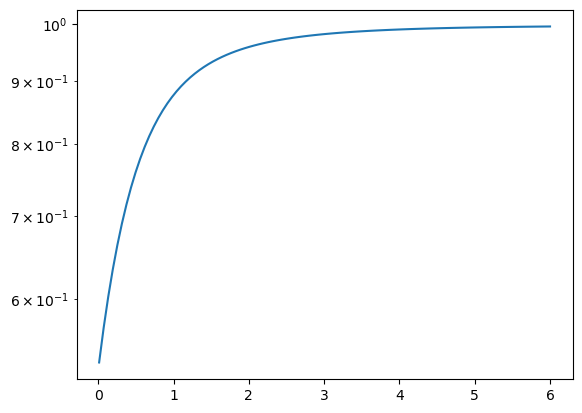

In [109]:
z = np.linspace(0.01, 6, 100)
plt.plot(z, cosmology.f(z, cosmo))
plt.yscale('log')

In [110]:
survey_design_bright = load(path + 'survey_design_Bright.pkl')
survey_design_grey = load(path + 'survey_design_Grey.pkl')
survey_design_dark = load(path + 'survey_design_Dark.pkl')

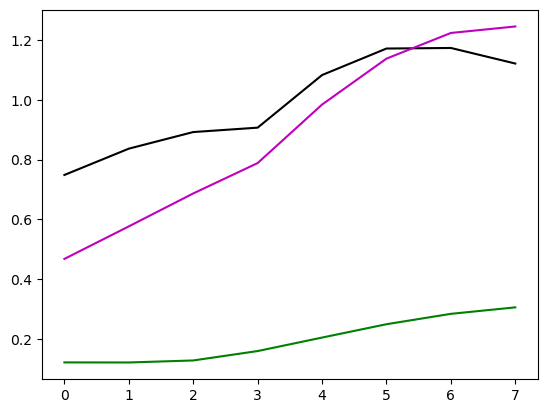

In [111]:
plt.plot(survey_design_dark['per_tracer_FnP']['LBGu_nP_eff_k0.001'], 'k')
plt.plot(survey_design_dark['per_tracer_FnP']['LBGg_nP_eff_k0.001'], 'm')
plt.plot(survey_design_dark['per_tracer_FnP']['LBGr_nP_eff_k0.001'], 'g')

In [112]:
mat_FnP_k1 = survey_design_dark['total_survey_Informations']['total_survey_information_FnP_k1']

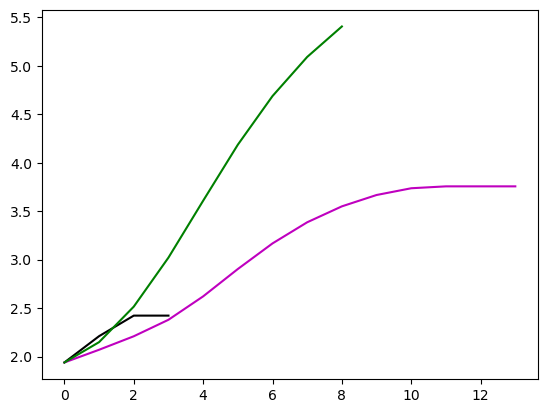

In [114]:
for k in [0.001]:
    mat_FnP_k = survey_design_grey[f'total_survey_Informations'][f'total_survey_information_FnP_k{k}']
    plt.plot( mat_FnP_k[:,0,0], 'k')
    plt.plot(mat_FnP_k[0,:,0], 'm')
    plt.plot(mat_FnP_k[0,0,:], 'g')


In [6]:
survey_design_bright[ 'per_tracer_forecasts'].keys()

dict_keys(['BG_bright_mag_max_eval', 'BG_bright_list_zbin_fnl', 'BG_bright_zeff_fnl', 'BG_bright_list_sigma_fnl', 'BG_bright_sigma_fnl_eff', 'BG_bright_list_zbin_Da', 'BG_bright_zeff_Da', 'BG_bright_list_sigma_Da', 'BG_bright_sigma_Da_eff', 'BG_bright_list_zbin_H', 'BG_bright_zeff_H', 'BG_bright_list_sigma_H', 'BG_bright_sigma_H_eff', 'BG_bright_list_zbin_Mnu', 'BG_bright_zeff_Mnu', 'BG_bright_list_sigma_Mnu', 'BG_bright_sigma_Mnu_eff', 'BG_bright_list_zbin_rsd', 'BG_bright_zeff_rsd', 'BG_bright_list_sigma_rsd', 'BG_bright_sigma_rsd_eff'])

Text(0.5, 0, '$\\sigma(\\sum M_\\nu)$')

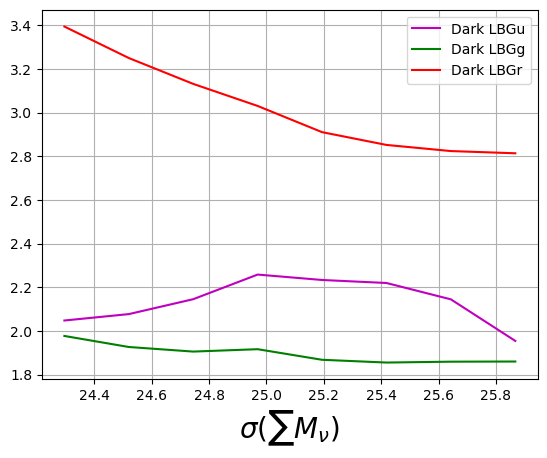

In [45]:
for survey in [survey_design_dark]:
    for i, tracer in enumerate(survey['config_survey']['tracers']):
        plt.plot(survey['config_survey'][tracer + '_mag_centers'], np.array(survey[ 'per_tracer_forecasts'][tracer + '_sigma_fnl_eff']), 
                 color = survey['config_survey']['color'][i], label = survey['config_survey']['survey_type'] + ' ' + tracer)
        
        #plt.plot(survey['config_survey'][tracer + '_mag_centers'], 100**np.array(survey[ 'per_tracer_forecasts'][tracer + '_sigma_rsd_eff']), 
        #         ls='--', color = survey['config_survey']['color'][i], label = survey['config_survey']['survey_type'] + ' ' + tracer)
plt.legend()
plt.grid()
plt.xlabel(r'$\sigma(\sum M_\nu)$', fontsize=20)

#plt.xlim(100, 0)

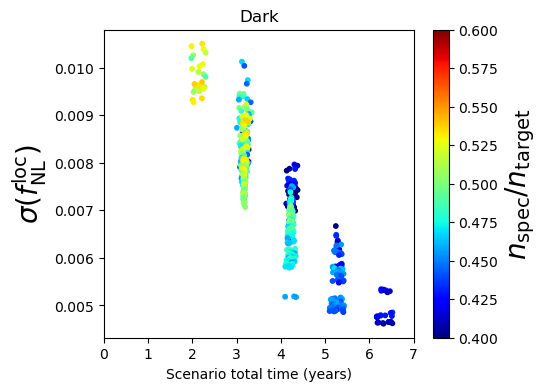

In [10]:
for survey in [survey_design_dark]:
    sigma_Da_target = 0.0006
    sigma_fnl_target = 1.1
    plt.figure(figsize=(5,4))
    Information_fnl = survey['total_survey_Informations']['total_survey_fisher_information_fnl']
    Information_Da = survey['total_survey_Informations']['total_survey_fisher_information_Da']
    Information_Mnu = survey['total_survey_Informations']['total_survey_fisher_information_Mnu']
    Information_rsd = survey['total_survey_Informations']['total_survey_fisher_information_rsd']
    total_time= survey['total_survey_Informations']['total_survey_time']
    total_survey_efficiency = survey['total_survey_Informations']['total_survey_efficiency']
    
    FoM_all = (sigma_fnl_target **2 * Information_fnl + sigma_Da_target **2 * Information_Da)
    FoM_fnl = sigma_fnl_target **2 * Information_fnl
    FoM_Da = sigma_Da_target **2 * Information_Da
    plt.title(survey['config_survey']['survey_type'])
    x = 2*np.random.random(len(total_time.flatten())) -1
    #plt.scatter(total_time.flatten() + 0.2*x*np.linspace(-1, 1, len(total_time.flatten())),  1/Information_fnl**.5,c= total_survey_efficiency.flatten(), s=10, label = 'Combined', cmap='jet', vmax=1, vmin=0.4)
    plt.scatter(total_time.flatten() + 0.2*x*np.linspace(-1, 1, len(total_time.flatten())),  1/Information_rsd**.5,c= total_survey_efficiency.flatten(), s=10, 
                label = 'Combined', cmap='jet', vmax=0.6, vmin=0.4)
    #plt.scatter(total_time.flatten() + 0.2*x*np.linspace(-1, 1, len(total_time.flatten())),  100*1/Information_rsd**.5,c= total_survey_efficiency.flatten(), s=10, label = 'Combined', cmap='jet', vmax=1, vmin=0.4)
    plt.ylabel(r'$\sigma(f_{\rm NL}^{\rm loc})$', fontsize=20)
    plt.ylabel(r'$\sigma(f_{\rm NL}^{\rm loc})$', fontsize=20)
    plt.xlabel(r'Scenario total time (years)', fontsize=10)
    cbar = plt.colorbar()
    cbar.set_label(r'$n_{\rm spec}/n_{\rm target}$', fontsize=20)
    plt.xlim(0, 7)

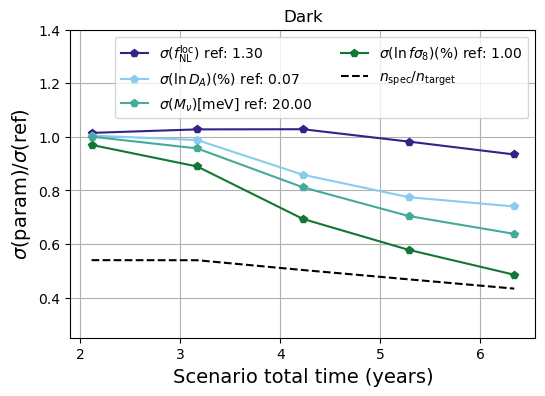

In [11]:
for survey in [ survey_design_dark,]:

    plt.figure(figsize=(6,4))

    Information_fnl = survey['total_survey_Informations']['total_survey_fisher_information_fnl']
    Information_Da = survey['total_survey_Informations']['total_survey_fisher_information_Da']
    Information_Mnu = survey['total_survey_Informations']['total_survey_fisher_information_Mnu']
    Information_rsd = survey['total_survey_Informations']['total_survey_fisher_information_rsd']

    colors = [
    "#332288",  # dark blue
    "#88CCEE",  # light blue
    "#44AA99",  # teal
    "#117733",  # green
    "#999933",  # olive
    "#DDCC77",  # sand
    "#CC6677",  # rose
    "#882255",  # wine
    "#AA4499",  # magenta
    "#661100",  # dark brown
    ]

    Informations = [
        Information_fnl,
        Information_Da / (100**2),
        Information_Mnu / (1000**2),
        Information_rsd / (100**2),
    ]

    labels = [r'$\sigma(f_{\rm NL}^{\rm loc})$', r'$\sigma(\ln D_A) (\%)$', r'$\sigma(M_\nu)$[meV]', r'$\sigma(\ln f\sigma_8) (\%)$']
    error_base = [1.3, 0.07, 20, 1]

    total_time = survey['total_survey_Informations']['total_survey_time']
    total_survey_efficiency = survey['total_survey_Informations']['total_survey_efficiency']

    plt.title(survey['config_survey']['survey_type'])

    unique_total_time = np.unique(total_time)

    for k, info in enumerate(Informations):

        times = []
        errors = []
        efficiency = []

        for t_survey in unique_total_time:

            mask_time = total_time.flatten() == t_survey

            error = 1 / np.sqrt(info.flatten()[mask_time])
            efficiency_ = total_survey_efficiency.flatten()[mask_time]


            best_idx = np.argmin(error)
            best_idx = np.argmax(efficiency_)

            times.append(t_survey)
            errors.append(error[best_idx])
            efficiency.append(efficiency_[best_idx])

        plt.plot(times,np.array( errors )/error_base[k], '-p', color=colors[k], label=labels[k] +F' ref: ${error_base[k]:.2F}$')
        #if k ==0: plt.plot(times, efficiency, '--',color=colors[k], label = r'$n_{\rm spec}/n_{\rm target}$')
    plt.plot(times, efficiency, '--',color='k', label = r'$n_{\rm spec}/n_{\rm target}$')
    plt.legend(ncols=2)
    plt.xlabel(r'Scenario total time (years)', fontsize=14)
    plt.grid()
    plt.ylabel(r'$\sigma$(param)/$\sigma$(ref)', fontsize=14)
    #plt.xlim(0, 7)
    plt.ylim(0.25, 1.4)